# Variational Quantum Classifier (VQC) for UNSW-NB15 (Full Scale)

This notebook implements a **Hybrid Quantum-Classical Classifier** for Network Intrusion Detection using PennyLane on the full UNSW-NB15 dataset.

**Model Architecture:**
- Classical Preprocessing: Encoding and Dimensionality reduction (→ 8 features via PCA)
- Quantum Circuit: 8-qubit variational circuit with strongly-entangling layers
- Classical Postprocessing: Dense layers for final classification

**Dataset:** UNSW-NB15 (Full Dataset Training)  
**Task:** Binary Classification (Normal vs Attack)  
**Framework:** PennyLane + PyTorch

## 1. Setup and Imports

In [1]:
import sys
import os
from pathlib import Path
import pickle
from tqdm.auto import tqdm

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# PennyLane for Quantum ML
try:
    import pennylane as qml
    from pennylane import numpy as pnp
    print(f"PennyLane version: {qml.__version__}")
    PENNYLANE_AVAILABLE = True
except ImportError:
    print("WARNING: PennyLane not installed. Install with: pip install pennylane")
    PENNYLANE_AVAILABLE = False

# Import custom models
from src.models.quantum.pennylane_models import HybridQuantumClassifier

sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("All modules loaded successfully!")

PennyLane version: 0.43.2
All modules loaded successfully!


## 2. Data Loading

In [2]:
DATA_DIR = project_root / 'data' / 'raw' / 'unsw-nb15'

train_path = DATA_DIR / 'UNSW_NB15_training-set.csv'
test_path = DATA_DIR / 'UNSW_NB15_testing-set.csv'

print(f"Loading full data from {DATA_DIR}...")
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Full Train shape: {train_df.shape}")
print(f"Full Test shape: {test_df.shape}")
train_df.head()

Loading full data from c:\Users\musab\Projects\NIDS-DL\data\raw\unsw-nb15...
Full Train shape: (82332, 45)
Full Test shape: (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


## 3. Preprocessing

In [3]:
def preprocess_unsw(df, encoders=None):
    df = df.copy()
    # Remove ID
    if 'id' in df.columns: df = df.drop('id', axis=1)
    if 'attack_cat' in df.columns: df = df.drop('attack_cat', axis=1)
    
    categorical_cols = ['proto', 'service', 'state']
    
    if encoders is None:
        encoders = {}
        for col in categorical_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
    else:
        for col in categorical_cols:
            le = encoders[col]
            df[col] = df[col].astype(str).map(lambda x: x if x in le.classes_ else le.classes_[0])
            df[col] = le.transform(df[col])
            
    return df, encoders

train_proc, unsw_encoders = preprocess_unsw(train_df)
test_proc, _ = preprocess_unsw(test_df, unsw_encoders)

X_train_raw = train_proc.drop('label', axis=1)
y_train = train_proc['label'].values
X_test_raw = test_proc.drop('label', axis=1)
y_test = test_proc['label'].values

print("Encoding complete.")

Encoding complete.


### Full Dataset Utilization
We are now using the entire dataset for training and testing. Class balancing logic remains to ensure model robustess.

In [4]:
def balanced_full_sample(X, y):
    idx = np.arange(len(y))
    idx0 = idx[y == 0]
    idx1 = idx[y == 1]
    
    # Use the maximum possible samples while maintaining balance
    min_class_size = min(len(idx0), len(idx1))
    
    s0 = np.random.choice(idx0, min_class_size, replace=False)
    s1 = np.random.choice(idx1, min_class_size, replace=False)
    
    s = np.concatenate([s0, s1])
    np.random.shuffle(s)
    return X.iloc[s], y[s]

print("Selecting balanced training set from full data...")
X_train_full, y_train_full = balanced_full_sample(X_train_raw, y_train)
X_test_full, y_test_full = balanced_full_sample(X_test_raw, y_test)

print(f"Final Training Size: {X_train_full.shape[0]} samples")
print(f"Final Testing Size: {X_test_full.shape[0]} samples")

Selecting balanced training set from full data...
Final Training Size: 74000 samples
Final Testing Size: 112000 samples


### Scaling and PCA

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

N_QUBITS = 8
pca = PCA(n_components=N_QUBITS)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA (dim={N_QUBITS}) completed. Total explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")

PCA (dim=8) completed. Total explained variance: 0.6972


## 4. Hybrid VQC Model Creation

In [6]:
# Convert to Tensors
X_train_tensor = torch.FloatTensor(X_train_pca)
y_train_tensor = torch.LongTensor(y_train_full)
X_test_tensor = torch.FloatTensor(X_test_pca)
y_test_tensor = torch.LongTensor(y_test_full)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

# Optimize PennyLane Device if possible
try:
    if torch.cuda.is_available():
        print("CUDA detected. Simulation will be hardware accelerated where possible (use lightning.gpu if installed).")
except:
    pass

model = HybridQuantumClassifier(
    input_dim=N_QUBITS, 
    num_classes=2, 
    n_qubits=N_QUBITS, 
    n_quantum_layers=2
)

print(model)

CUDA detected. Simulation will be hardware accelerated where possible (use lightning.gpu if installed).
HybridQuantumClassifier(
  (preprocessing): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=8, bias=True)
    (7): Tanh()
  )
  (postprocessing): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=2, bias=True)
  )
)


## 5. Training (Unconstrained Large Scale)

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)
epochs = 10 

history = {'loss': [], 'accuracy': []}

print("Starting FULL SCALE quantum-hybrid training...")
epoch_pbar = tqdm(range(epochs), desc='Training Hybrid VQC (Full Dataset)')

for epoch in epoch_pbar:
    model.train()
    total_loss = 0
    correct = 0
    
    batch_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}', leave=False)
    for X_batch, y_batch in batch_pbar:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        current_correct = (preds == y_batch).sum().item()
        correct += current_correct
        
        batch_pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    avg_loss = total_loss / len(train_loader)
    accuracy = correct / len(train_loader.dataset)
    history['loss'].append(avg_loss)
    history['accuracy'].append(accuracy)
    
    epoch_pbar.set_postfix({'loss': f"{avg_loss:.4f}", 'acc': f"{accuracy:.4f}"})


Starting FULL SCALE quantum-hybrid training...


Training Hybrid VQC (Full Dataset):   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/1157 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/1157 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/1157 [00:00<?, ?it/s]

...

Epoch 6:   0%|          | 0/1157 [00:00<?, ?it/s]

Epoch 7:   0%|          | 0/1157 [00:00<?, ?it/s]

Epoch 8:   0%|          | 0/1157 [00:00<?, ?it/s]

Epoch 9:   0%|          | 0/1157 [00:00<?, ?it/s]

Epoch 10:   0%|          | 0/1157 [00:00<?, ?it/s]

## 6. Evaluation

Evaluating on Full Test Set:   0%|          | 0/1750 [00:00<?, ?it/s]

Classification Report (Full Scale):
              precision    recall  f1-score   support

           0       0.79      0.97      0.87     56000
           1       0.96      0.75      0.84     56000

    accuracy                           0.86    112000
   macro avg       0.88      0.86      0.86    112000
weighted avg       0.88      0.86      0.86    112000



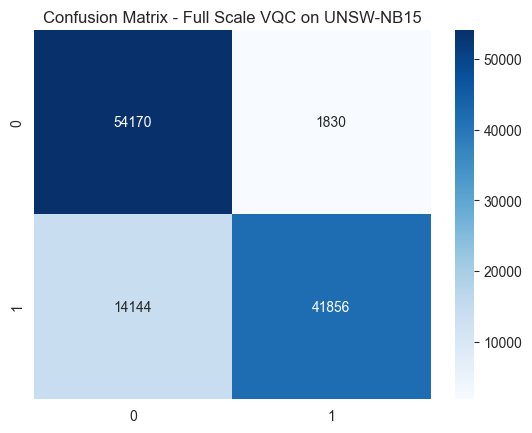

In [8]:
model.eval()
all_preds = []
with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader, desc='Evaluating on Full Test Set'):
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.numpy())

print("Classification Report (Full Scale):")
print(classification_report(y_test_full, all_preds))

cm = confusion_matrix(y_test_full, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Full Scale VQC on UNSW-NB15')
plt.show()

## 7. Saving Final Artifacts

In [9]:
SAVE_DIR = project_root / 'results' / 'models' / 'quantum'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_path = SAVE_DIR / f'vqc_hybrid_unsw_full_{timestamp}.pt'
pre_path = SAVE_DIR / f'vqc_unsw_preprocessing_full_{timestamp}.pkl'

torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_dim': N_QUBITS,
        'num_classes': 2,
        'n_qubits': N_QUBITS,
        'n_quantum_layers': 2
    }
}, model_path)

with open(pre_path, 'wb') as f:
    pickle.dump({
        'scaler': scaler,
        'pca': pca,
        'encoders': unsw_encoders,
        'feature_cols': X_train_raw.columns.tolist()
    }, f)

print(f"Final Model saved to: {model_path}")

Final Model saved to: c:\Users\musab\Projects\NIDS-DL\results\models\quantum\vqc_hybrid_unsw_full_20260411_070104.pt


In [10]:
torch.cuda.empty_cache()
import gc
gc.collect()

4287